<a href="https://colab.research.google.com/github/Janani-Hendeniya/230238R_EN2550_Assignment_01/blob/main/230238R_a01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Question 01**

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
im = cv2.imread("emma.jpg")
print(im.shape)

(810, 720, 3)


<function matplotlib.pyplot.show(close=None, block=None)>

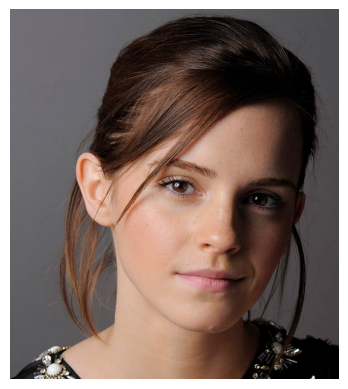

In [3]:
plt.imshow(cv2.cvtColor(im,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show

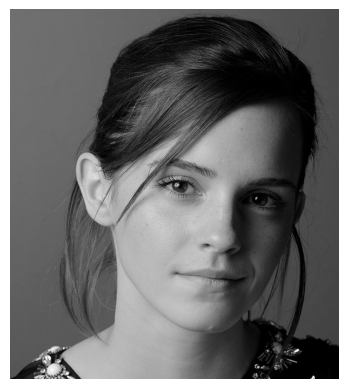

In [4]:
gray = cv2.cvtColor(im,cv2.COLOR_BGR2GRAY)
plt.imshow(gray,cmap = "gray")
plt.axis("off")
plt.show()

In [5]:
print(gray.shape)
print(gray.dtype)
print(gray.min())
print(gray.max())

(810, 720)
uint8
0
255


In [6]:
breakpoints = np.array([
    [0,0],
    [50,50],
    [50,100],
    [150,255],
    [150,150],
    [255,255]
])

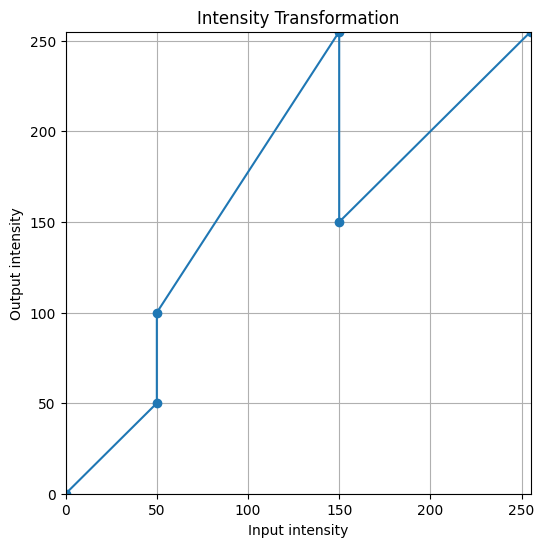

In [7]:
x = breakpoints[:,0]
y = breakpoints[:,1]
plt.figure(figsize=(6,6))
plt.plot(x,y,marker = "o")
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Intensity Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.grid()
plt.show()

In [8]:
def intensity_transform(im, breakpoints):

    breakpoints = np.array(breakpoints)

    x_points = breakpoints[:, 0]
    y_points = breakpoints[:, 1]

    lut = np.interp(np.arange(256), x_points, y_points)

    lut = np.uint8(lut)

    transformed = lut[im]

    return transformed

In [9]:
transformed = intensity_transform(gray, breakpoints)

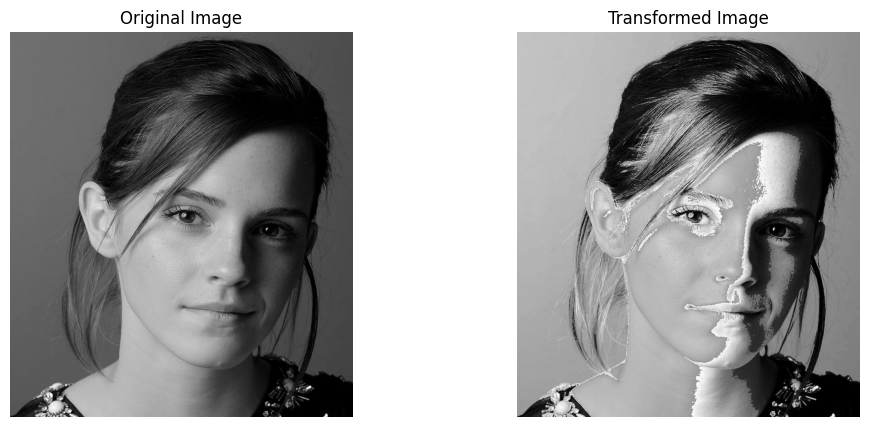

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transformed, cmap="gray")
plt.title("Transformed Image")
plt.axis("off")

plt.show()

**Experimenting with intensity transformations**


**A) More visually pleasing output**

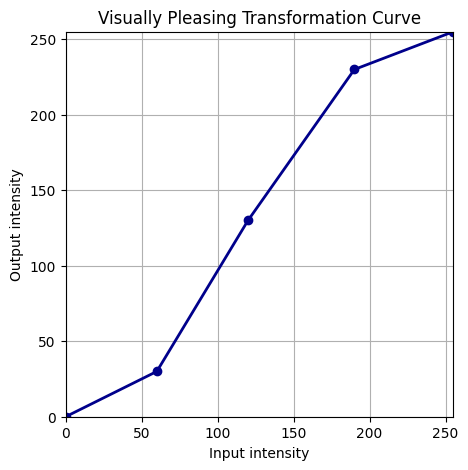

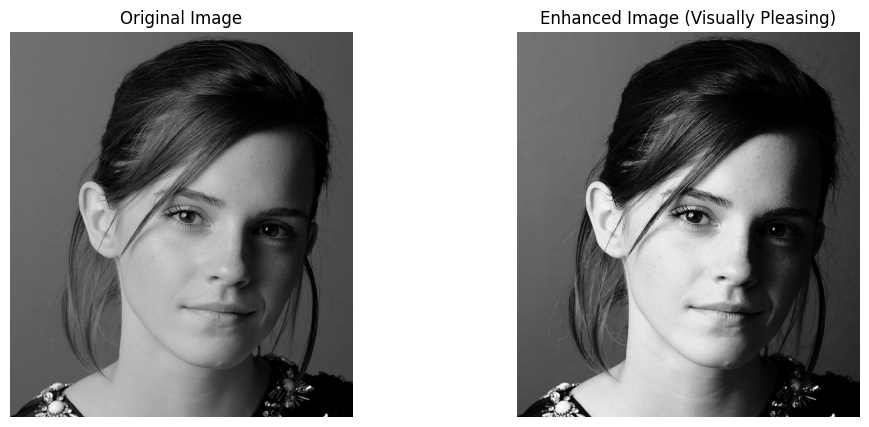

In [11]:
pleasing_breakpoints = np.array(
    [[0, 0], [60, 30], [120, 130], [190, 230], [255, 255]]
)

transformed = intensity_transform(gray, pleasing_breakpoints)

plt.figure(figsize = (5,5))
plt.plot(
    pleasing_breakpoints[:,0],
    pleasing_breakpoints[:,1],
    "o-",
    color="darkblue",
    linewidth=2,

)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Visually Pleasing Transformation Curve")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
plt.show()

# Figure 2: Side-by-side image comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transformed, cmap="gray")
plt.title("Enhanced Image (Visually Pleasing)")
plt.axis("off")

plt.show()

**B) Brightening Dark Areas**

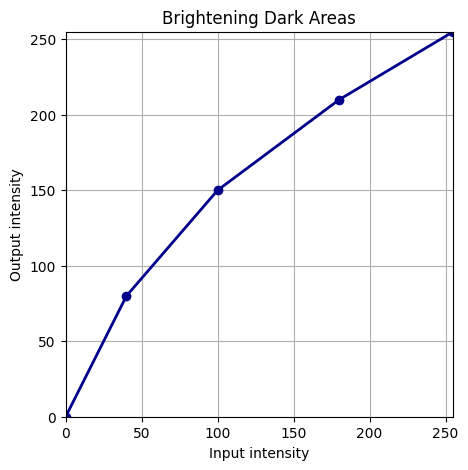

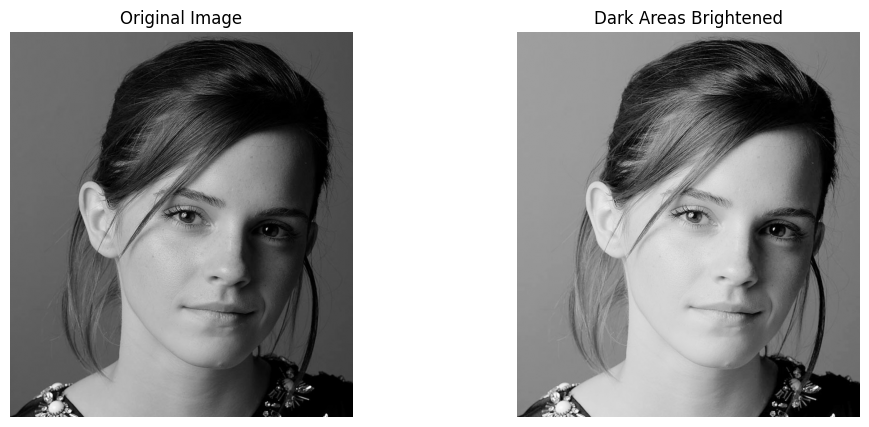

In [12]:
shadow_lift_breakpoints = np.array(
  [[0, 0], [40, 80], [100, 150], [180, 210], [255, 255]]
)

transformed = intensity_transform(gray, shadow_lift_breakpoints)

plt.figure(figsize = (5,5))
plt.plot(
    shadow_lift_breakpoints[:,0],
    shadow_lift_breakpoints[:,1],
    "o-",
    color="darkblue",
    linewidth=2,

)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Brightening Dark Areas")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
plt.show()

# Figure 2: Side-by-side image comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transformed, cmap="gray")
plt.title("Dark Areas Brightened")
plt.axis("off")

plt.show()

**C) Posterization Effect**

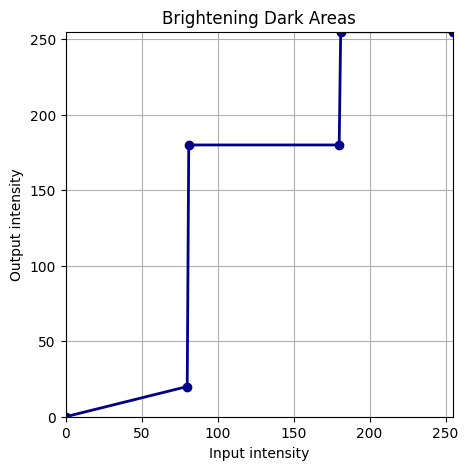

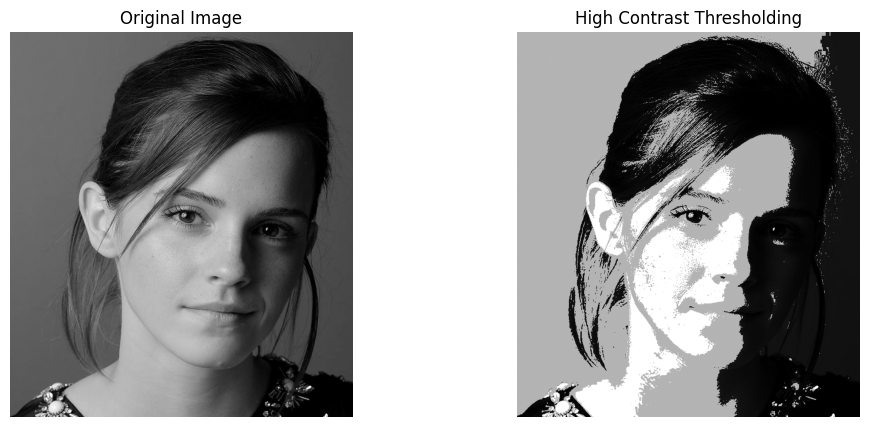

In [13]:
posterize_breakpoints = np.array(
  [[0, 0], [80, 20], [81, 180], [180, 180], [181, 255], [255, 255]]
)

transformed = intensity_transform(gray, posterize_breakpoints)

plt.figure(figsize = (5,5))
plt.plot(
    posterize_breakpoints[:,0],
    posterize_breakpoints[:,1],
    "o-",
    color="darkblue",
    linewidth=2,

)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Brightening Dark Areas")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
plt.show()

# Figure 2: Side-by-side image comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transformed, cmap="gray")
plt.title("High Contrast Thresholding")
plt.axis("off")

plt.show()

**Question 02**

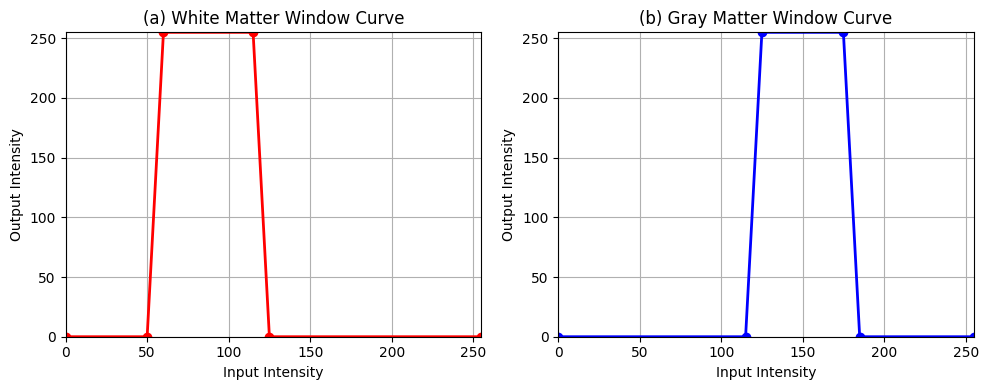

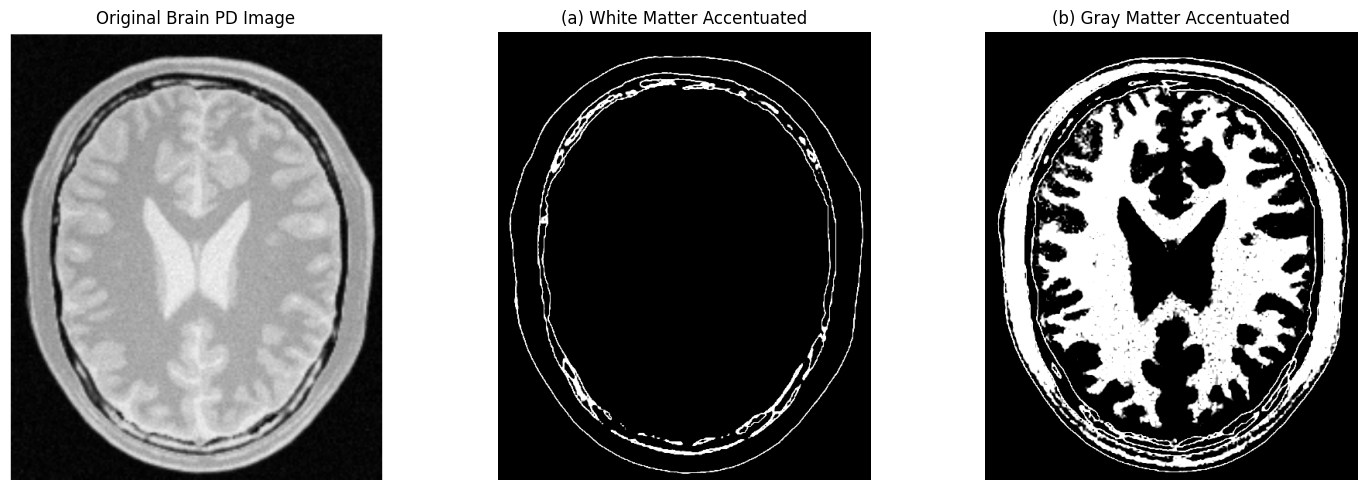

In [14]:
brain_image = cv2.imread("brain.png",cv2.IMREAD_GRAYSCALE)

#Elevating White Matter
breakpoints_wm = np.array(
    [[0, 0], [50, 0], [60, 255], [115, 255], [125, 0], [255, 0]]
    )
wm_accentuated = intensity_transform(brain_image, breakpoints_wm)

#elevating gray matter
breakpoints_gm = np.array(
    [[0, 0], [115, 0], [125, 255], [175, 255], [185, 0], [255, 0]]
)
gm_accentuated = intensity_transform(brain_image, breakpoints_gm)

#plotting the intensity transformation

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(
    breakpoints_wm[:, 0], breakpoints_wm[:, 1], "r-o", linewidth=2
)
axes[0].set_title("(a) White Matter Window Curve")
axes[0].set_xlabel("Input Intensity")
axes[0].set_ylabel("Output Intensity")
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].grid(True)

axes[1].plot(
    breakpoints_gm[:, 0], breakpoints_gm[:, 1], "b-o", linewidth=2
)
axes[1].set_title("(b) Gray Matter Window Curve")
axes[1].set_xlabel("Input Intensity")
axes[1].set_ylabel("Output Intensity")
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 255)
axes[1].grid(True)

plt.tight_layout()
plt.show()

#image results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(brain_image, cmap="gray")
axes[0].set_title("Original Brain PD Image")
axes[0].axis("off")

axes[1].imshow(wm_accentuated, cmap="gray")
axes[1].set_title("(a) White Matter Accentuated")
axes[1].axis("off")

axes[2].imshow(gm_accentuated, cmap="gray")
axes[2].set_title("(b) Gray Matter Accentuated")
axes[2].axis("off")

plt.tight_layout()
plt.show()


**Question 03**

<>:26: SyntaxWarning: invalid escape sequence '\g'
<>:36: SyntaxWarning: invalid escape sequence '\g'
<>:26: SyntaxWarning: invalid escape sequence '\g'
<>:36: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_872/429997567.py:26: SyntaxWarning: invalid escape sequence '\g'
  axes[0, 1].set_title(f"Gamma Corrected L* plane ($\gamma = {gamma}$)")
/tmp/ipykernel_872/429997567.py:36: SyntaxWarning: invalid escape sequence '\g'
  axes[1, 1].set_title(f"Corrected L* Histogram ($\gamma = {gamma}$)")


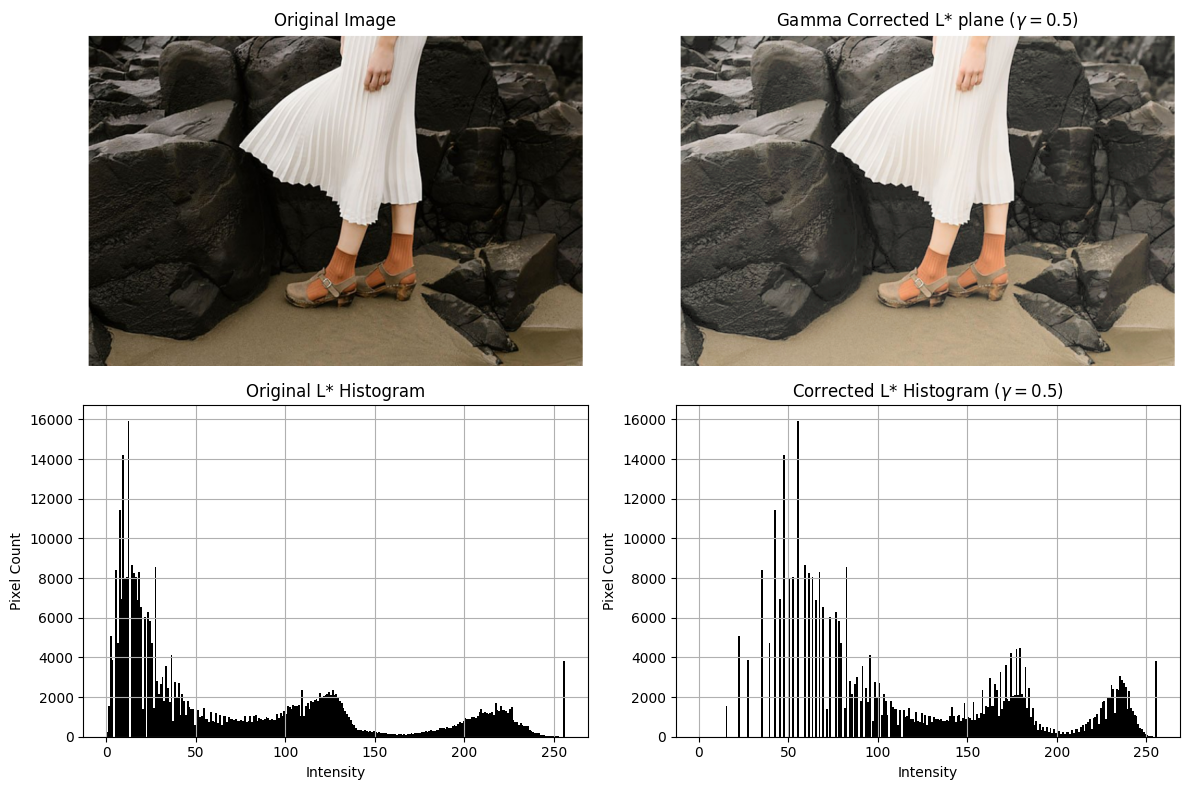

In [15]:
img_bgr = cv2.imread("problem3.png")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

#applying gamma correction to L* plane
#choosing gamma = 0.5 to brighten dark shadow regions
gamma = 0.5
L_normalized = L/255.0
L_gamma = np.uint8(np.power(L_normalized, gamma)*255)

#merging channels back together
lab_corrected = cv2.merge([L_gamma, a, b])
img_corrected_bgr = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)
img_corrected_rgb = cv2.cvtColor(img_corrected_bgr, cv2.COLOR_BGR2RGB)

#display
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_corrected_rgb)
axes[0, 1].set_title(f"Gamma Corrected L* plane ($\gamma = {gamma}$)")
axes[0, 1].axis("off")

axes[1, 0].hist(L.ravel(), bins=256, range=[0, 256], color="black")
axes[1, 0].set_title("Original L* Histogram")
axes[1, 0].set_xlabel("Intensity")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].grid(True)

axes[1, 1].hist(L_gamma.ravel(), bins=256, range=[0, 256], color="black")
axes[1, 1].set_title(f"Corrected L* Histogram ($\gamma = {gamma}$)")
axes[1, 1].set_xlabel("Intensity")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### Gamma Correction Justification

The image has a large contrast between the dark volcanic rocks and the bright white skirt. The \(L^*\) histogram is mainly concentrated in the lower intensity range, making details in the darker areas difficult to see.

I chose \(\gamma = 0.5\) because \(\gamma < 1\) increases the brightness of darker pixels more than brighter pixels. This helps reveal the texture and details in the rocks while keeping the already bright areas relatively less affected. The \(a^*\) and \(b^*\) channels were kept unchanged to preserve the original colour information.


**Question 04**\
a)Splitting the image into HSV planes

In [16]:
im_bgr = cv2.imread("spiderman.png")
im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
im_hsv = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2HSV)

# Split into individual H, S, V planes
H, S, V = cv2.split(im_hsv)

b)Applying intensity transformation to the saturation plane

In [17]:
a = 0.2
sigma = 70.0
x = np.arange(256, dtype=np.float32)
#transformation
gaussian_boost = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma**2)))
lut = np.clip(x + gaussian_boost, 0, 255).astype(np.uint8)

S_transformed = lut[S]


c)Adjust a to get a visually pleasing output and report a

when a = 0.2

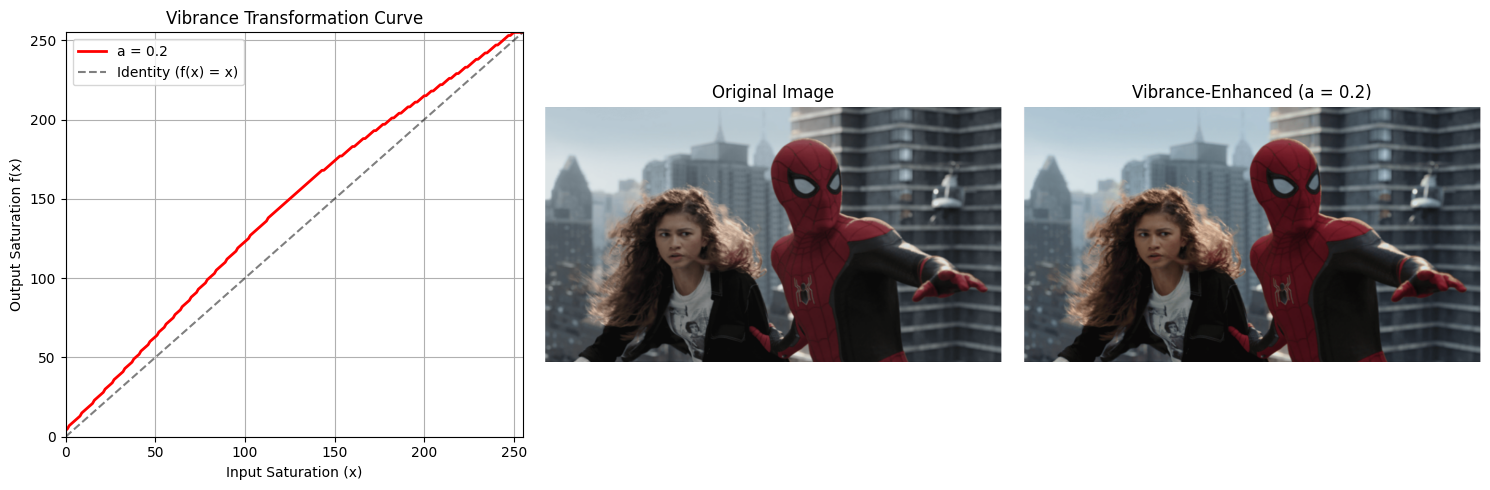

In [18]:
a = 0.2
sigma = 70.0
x = np.arange(256, dtype=np.float32)
#transformation
gaussian_boost = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma**2)))
lut = np.clip(x + gaussian_boost, 0, 255).astype(np.uint8)

S_transformed = lut[S]
hsv_transformed = cv2.merge([H, S_transformed, V])
img_vibrant_rgb = cv2.cvtColor(hsv_transformed, cv2.COLOR_HSV2RGB)
plt.figure(figsize=(15, 5))

# 1. Intensity Transformation Curve Plot
plt.subplot(1, 3, 1)
plt.plot(x, lut, "r-", linewidth=2, label=f"a = {a}")
plt.plot([0, 255], [0, 255], "k--", alpha=0.5, label="Identity (f(x) = x)")
plt.title("Vibrance Transformation Curve")
plt.xlabel("Input Saturation (x)")
plt.ylabel("Output Saturation f(x)")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
plt.legend()

# 2. Original Image
plt.subplot(1, 3, 2)
plt.imshow(im_rgb)
plt.title("Original Image")
plt.axis("off")

# 3. Vibrance-Enhanced Image
plt.subplot(1, 3, 3)
plt.imshow(img_vibrant_rgb)
plt.title(f"Vibrance-Enhanced (a = {a})")
plt.axis("off")

plt.tight_layout()
plt.show()

When a = 0.5

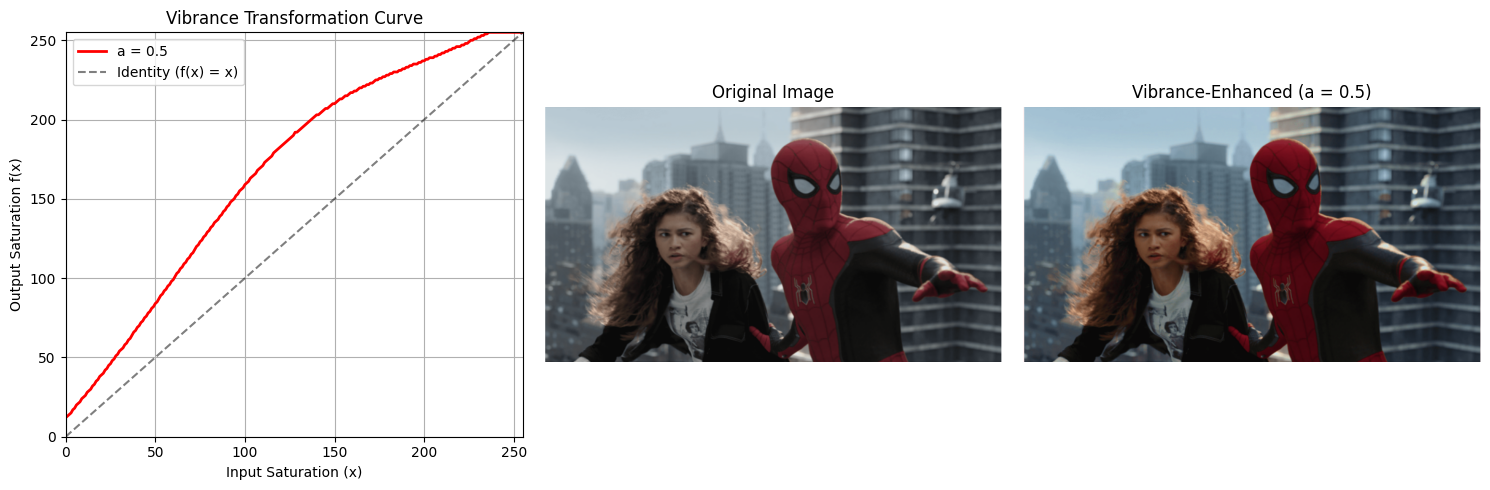

In [19]:
a = 0.5
sigma = 70.0
x = np.arange(256, dtype=np.float32)
#transformation
gaussian_boost = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma**2)))
lut = np.clip(x + gaussian_boost, 0, 255).astype(np.uint8)

S_transformed = lut[S]
hsv_transformed = cv2.merge([H, S_transformed, V])
img_vibrant_rgb = cv2.cvtColor(hsv_transformed, cv2.COLOR_HSV2RGB)
plt.figure(figsize=(15, 5))

# 1. Intensity Transformation Curve Plot
plt.subplot(1, 3, 1)
plt.plot(x, lut, "r-", linewidth=2, label=f"a = {a}")
plt.plot([0, 255], [0, 255], "k--", alpha=0.5, label="Identity (f(x) = x)")
plt.title("Vibrance Transformation Curve")
plt.xlabel("Input Saturation (x)")
plt.ylabel("Output Saturation f(x)")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
plt.legend()

# 2. Original Image
plt.subplot(1, 3, 2)
plt.imshow(im_rgb)
plt.title("Original Image")
plt.axis("off")

# 3. Vibrance-Enhanced Image
plt.subplot(1, 3, 3)
plt.imshow(img_vibrant_rgb)
plt.title(f"Vibrance-Enhanced (a = {a})")
plt.axis("off")

plt.tight_layout()
plt.show()

When a = 0.8

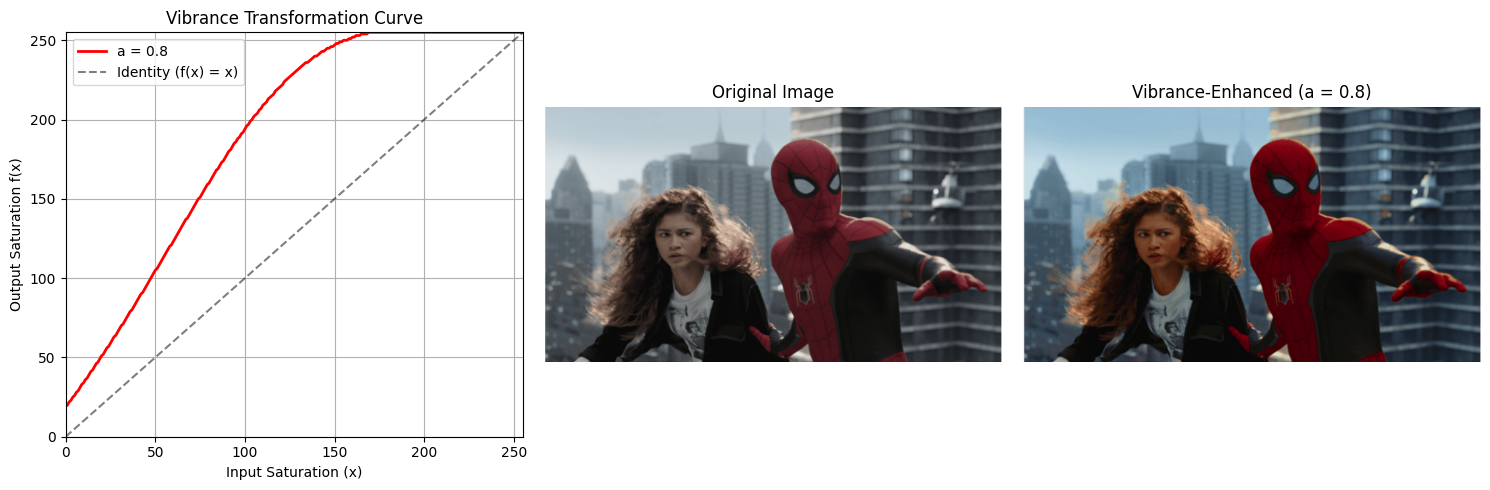

In [20]:
a = 0.8
sigma = 70.0
x = np.arange(256, dtype=np.float32)
#transformation
gaussian_boost = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma**2)))
lut = np.clip(x + gaussian_boost, 0, 255).astype(np.uint8)

S_transformed = lut[S]
hsv_transformed = cv2.merge([H, S_transformed, V])
img_vibrant_rgb = cv2.cvtColor(hsv_transformed, cv2.COLOR_HSV2RGB)
plt.figure(figsize=(15, 5))

# 1. Intensity Transformation Curve Plot
plt.subplot(1, 3, 1)
plt.plot(x, lut, "r-", linewidth=2, label=f"a = {a}")
plt.plot([0, 255], [0, 255], "k--", alpha=0.5, label="Identity (f(x) = x)")
plt.title("Vibrance Transformation Curve")
plt.xlabel("Input Saturation (x)")
plt.ylabel("Output Saturation f(x)")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
plt.legend()

# 2. Original Image
plt.subplot(1, 3, 2)
plt.imshow(im_rgb)
plt.title("Original Image")
plt.axis("off")

# 3. Vibrance-Enhanced Image
plt.subplot(1, 3, 3)
plt.imshow(img_vibrant_rgb)
plt.title(f"Vibrance-Enhanced (a = {a})")
plt.axis("off")

plt.tight_layout()
plt.show()

**Choice of parameter: (a = 0.5)\**

I chose (a = 0.5) because it gives a good balance between enhancement and saturation. With (a = 0.2), the enhancement was too small and the image remained close to the original. On the other hand, (a = 0.8) caused too much saturation, resulting in loss of some shading and natural skin tones. Therefore, (a = 0.5) was selected as it enhances the mid-tone regions while keeping the image details and colours relatively natural.

**Question 05**

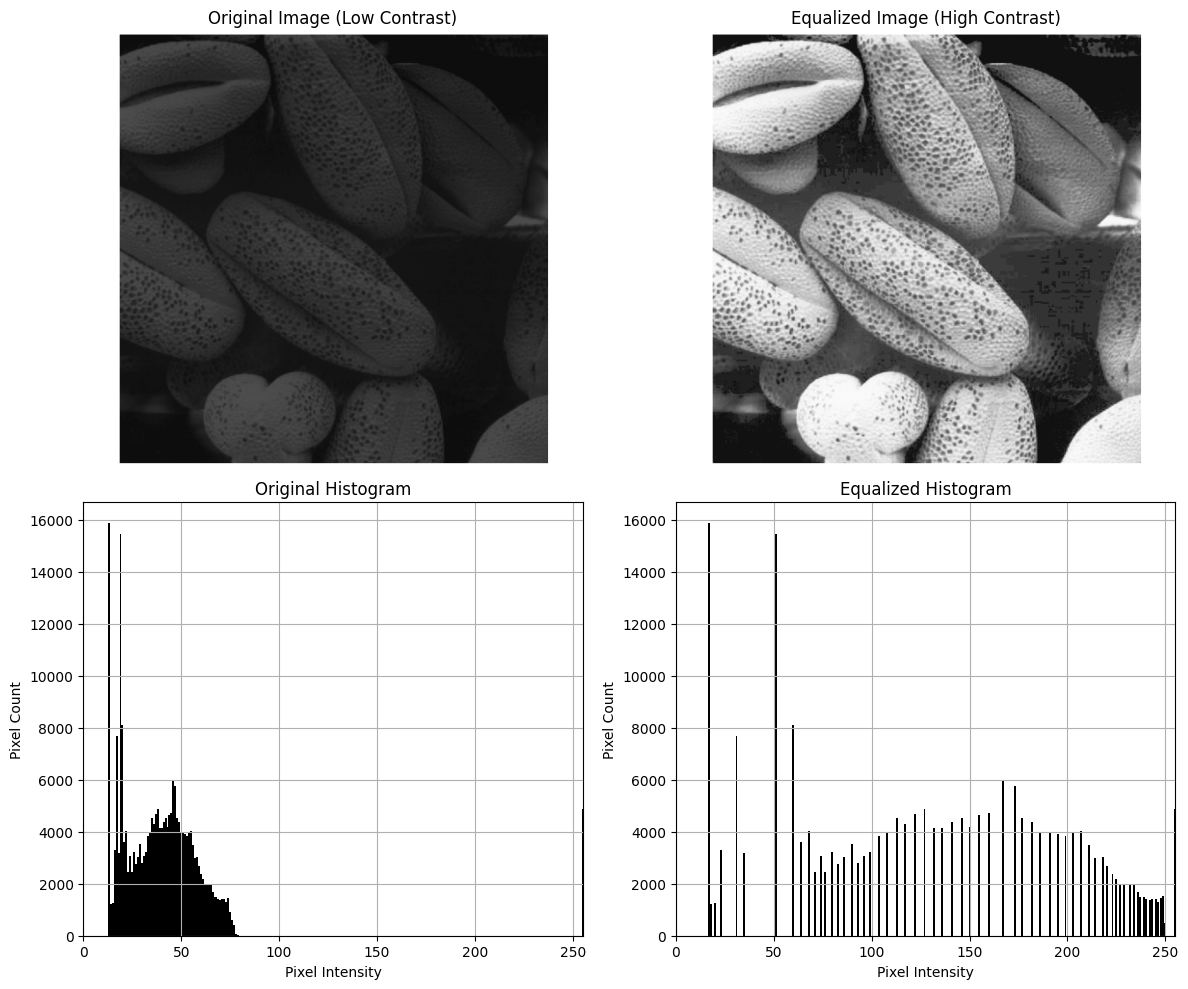

In [21]:
def custom_equalize_hist(img):
  hist, _ = np.histogram(img.ravel(), 256, [0, 256])
  pdf = hist / img.size
  cdf = np.cumsum(pdf)
  lut = np.round(cdf * 255).astype(np.uint8)
  equalized_img = lut[img]
  return equalized_img, hist
# Load pollen image in grayscale
img = cv2.imread("pollen.png", cv2.IMREAD_GRAYSCALE)

# Run custom histogram equalization
img_equalized, hist_original = custom_equalize_hist(img)

# Compute histogram of the equalized image for plotting
hist_equalized, _ = np.histogram(img_equalized.ravel(), 256, [0, 256])

# Display Images and Histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Original Image
axes[0, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original Image (Low Contrast)")
axes[0, 0].axis("off")

# 2. Equalized Image
axes[0, 1].imshow(img_equalized, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Equalized Image (High Contrast)")
axes[0, 1].axis("off")

# 3. Original Histogram
axes[1, 0].bar(range(256), hist_original, color="black", width=1.0)
axes[1, 0].set_title("Original Histogram")
axes[1, 0].set_xlabel("Pixel Intensity")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].set_xlim(0, 255)
axes[1, 0].grid(True)

# 4. Equalized Histogram
axes[1, 1].bar(range(256), hist_equalized, color="black", width=1.0)
axes[1, 1].set_title("Equalized Histogram")
axes[1, 1].set_xlabel("Pixel Intensity")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].set_xlim(0, 255)
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()



**Question 06**

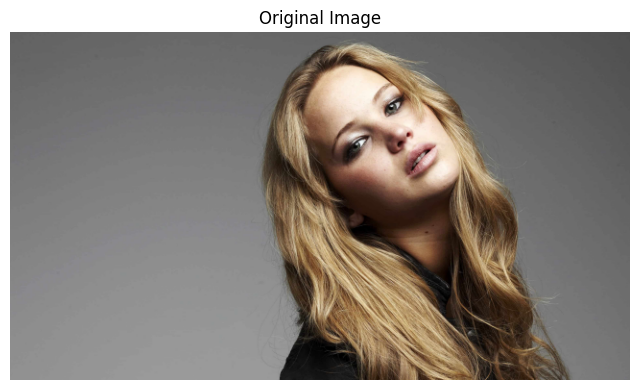

In [22]:
image = cv2.imread("jennifer.png")
plt.figure(figsize=(8,5))

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.show()

a) Convering the image to HSV

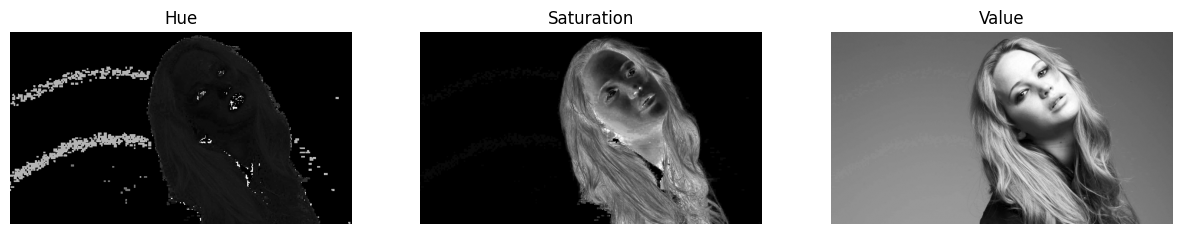

In [23]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)
#displaying H,S and V in grayscale
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(H, cmap='gray')
plt.title("Hue")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(S, cmap='gray')
plt.title("Saturation")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(V, cmap='gray')
plt.title("Value")
plt.axis("off")

plt.show()

b)
 saturation plane was selected for foreground extraction because the background is predominantly gray and therefore has low saturation, whereas the foreground contains regions with higher saturation. This provides better separation between the foreground and background compared with the hue and value planes.

c)

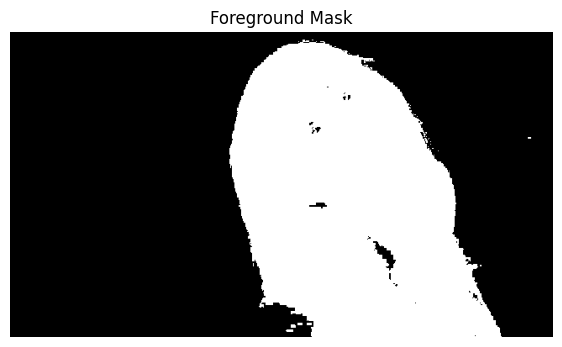

In [24]:
threshold = 11

_, mask = cv2.threshold(S, threshold, 255, cv2.THRESH_BINARY)
plt.figure(figsize=(7,4))

plt.imshow(mask, cmap='gray')
plt.title("Foreground Mask")
plt.axis("off")

plt.show()

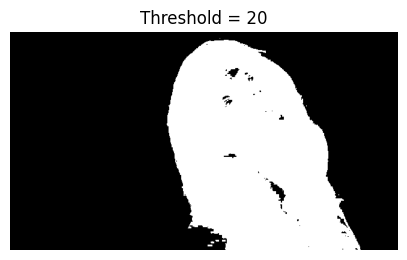

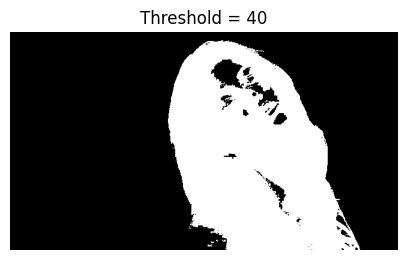

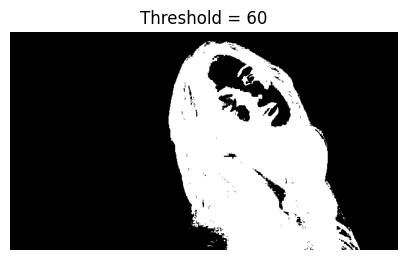

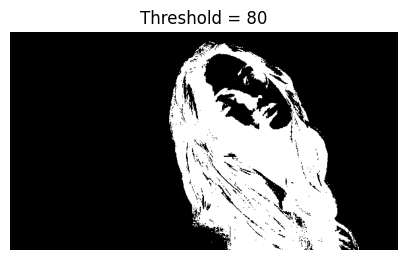

In [25]:
for t in [20, 40, 60, 80]:
    _, test_mask = cv2.threshold(S, t, 255, cv2.THRESH_BINARY)

    plt.figure(figsize=(5,3))
    plt.imshow(test_mask, cmap='gray')
    plt.title(f"Threshold = {t}")
    plt.axis("off")
    plt.show()

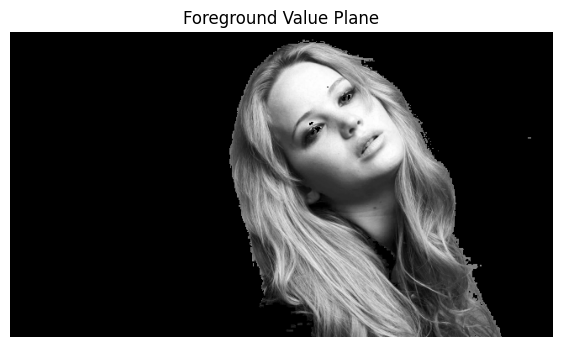

In [26]:
foreground = cv2.bitwise_and(V, V, mask=mask)
plt.figure(figsize=(7,4))

plt.imshow(foreground, cmap='gray')
plt.title("Foreground Value Plane")
plt.axis("off")

plt.show()

Calculating the histogram

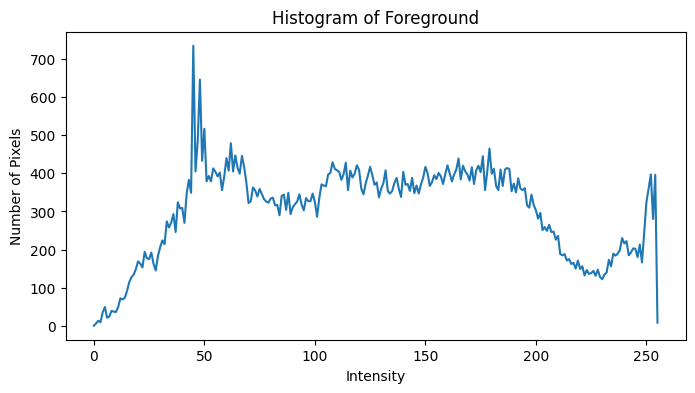

In [27]:
hist = cv2.calcHist([V], [0], mask, [256], [0,256])
plt.figure(figsize=(8,4))

plt.plot(hist)

plt.title("Histogram of Foreground")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.show()

d) Calculating the cumulative sum

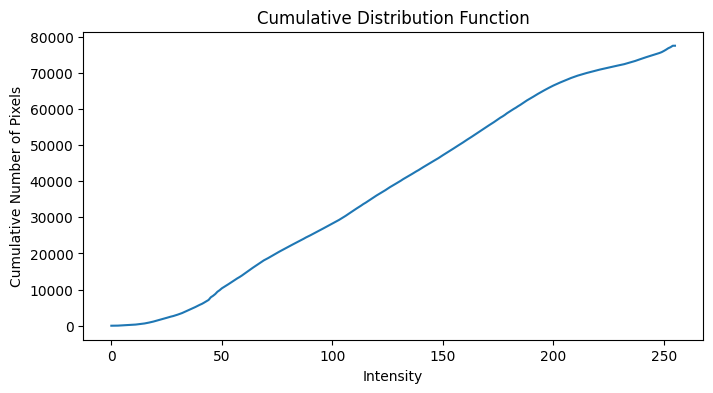

In [28]:
cdf = np.cumsum(hist)
plt.figure(figsize=(8,4))

plt.plot(cdf)

plt.title("Cumulative Distribution Function")
plt.xlabel("Intensity")
plt.ylabel("Cumulative Number of Pixels")

plt.show()

e) Histogram equalization

Number of foreground pixels: 77526


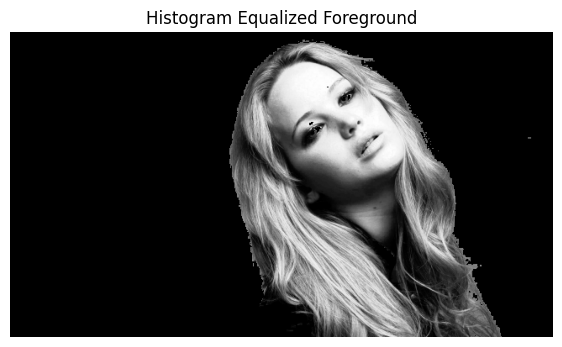

In [29]:
N = np.sum(mask > 0)
print("Number of foreground pixels:", N)
cdf_min = cdf[cdf > 0].min()
equalized_map = ((cdf - cdf_min) / (N - cdf_min) * 255)
equalized_map = np.clip(equalized_map, 0, 255)
equalized_map = equalized_map.astype(np.uint8)
equalized_foreground = equalized_map[V]
equalized_foreground = cv2.bitwise_and(
    equalized_foreground,
    equalized_foreground,
    mask=mask
)
plt.figure(figsize=(7,4))

plt.imshow(equalized_foreground, cmap='gray')
plt.title("Histogram Equalized Foreground")
plt.axis("off")

plt.show()

f)Extracting the background

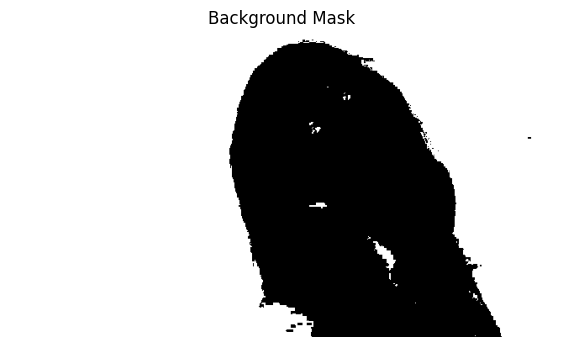

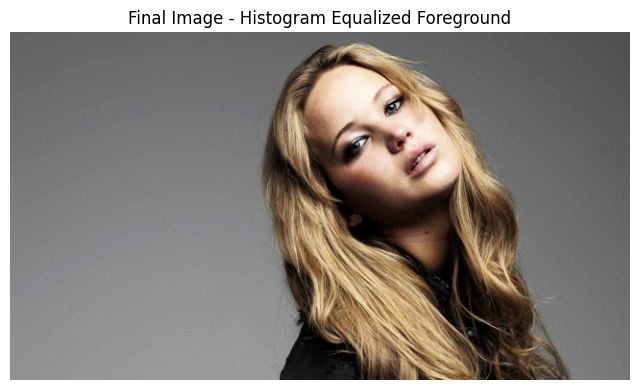

In [30]:
background_mask = cv2.bitwise_not(mask)
plt.figure(figsize=(7,4))

plt.imshow(background_mask, cmap='gray')
plt.title("Background Mask")
plt.axis("off")

plt.show()
background = cv2.bitwise_and(V, V, mask=background_mask)
result_V = cv2.add(background, equalized_foreground)
final_hsv = cv2.merge([H, S, result_V])
result = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)
plt.figure(figsize=(8,5))

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Final Image - Histogram Equalized Foreground")
plt.axis("off")

plt.show()

**Question 07**

a)

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

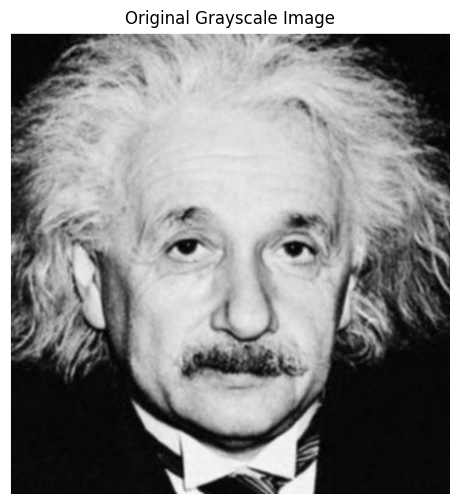

In [32]:
img = cv2.imread("einstein.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(6,6))
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()


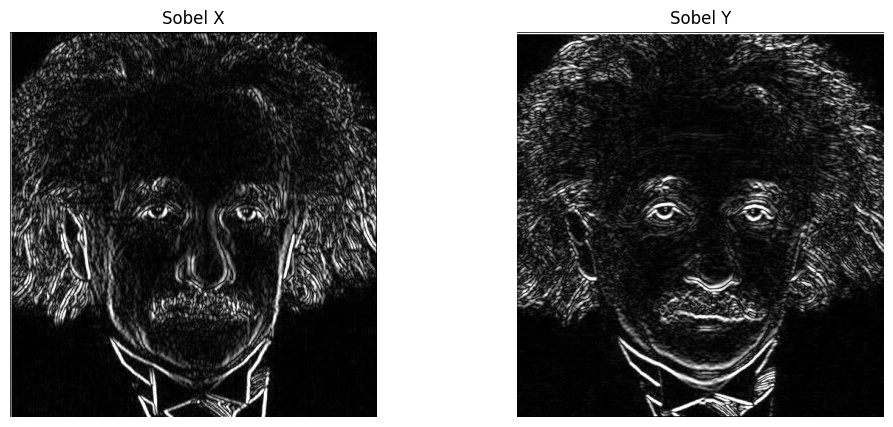

In [33]:
# Part (a) - Sobel filtering using cv2.filter2D

# Sobel X kernel
sobel_x = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)

# Sobel Y kernel
sobel_y = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# Apply Sobel X
gx = cv2.filter2D(gray, cv2.CV_32F, sobel_x)

# Apply Sobel Y
gy = cv2.filter2D(gray, cv2.CV_32F, sobel_y)

# Convert results to 8-bit images for display
gx_display = cv2.convertScaleAbs(gx)
gy_display = cv2.convertScaleAbs(gy)

# Display results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gx_display, cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gy_display, cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.show()

b)

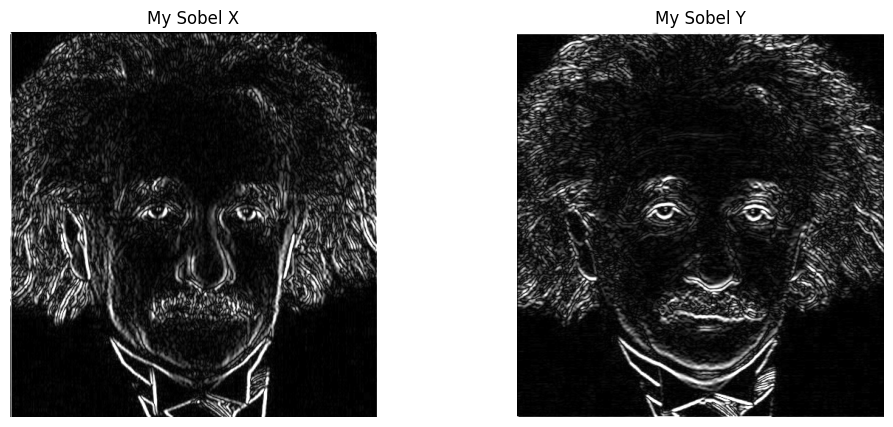

In [34]:
# Part (b) - Own Sobel filtering code

def my_filter(image, kernel):

    # Get image dimensions
    rows, cols = image.shape

    # Get kernel dimensions
    krows, kcols = kernel.shape

    # Calculate padding
    pad_r = krows // 2
    pad_c = kcols // 2

    # Pad the image with zeros
    padded = np.pad(
        image,
        ((pad_r, pad_r), (pad_c, pad_c)),
        mode="constant"
    )

    # Create output image
    output = np.zeros(
        (rows, cols),
        dtype=np.float32
    )

    # Move the kernel over every pixel
    for i in range(rows):

        for j in range(cols):

            # Extract current region
            region = padded[
                i:i+krows,
                j:j+kcols
            ]

            # Multiply and add
            output[i, j] = np.sum(
                region * kernel
            )

    return output


# Apply our own filter using Sobel X
gx_manual = my_filter(gray, sobel_x)

# Apply our own filter using Sobel Y
gy_manual = my_filter(gray, sobel_y)


# Convert results for display
gx_manual_display = cv2.convertScaleAbs(gx_manual)
gy_manual_display = cv2.convertScaleAbs(gy_manual)


# Display results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gx_manual_display, cmap="gray")
plt.title("My Sobel X")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gy_manual_display, cmap="gray")
plt.title("My Sobel Y")
plt.axis("off")

plt.show()

c)

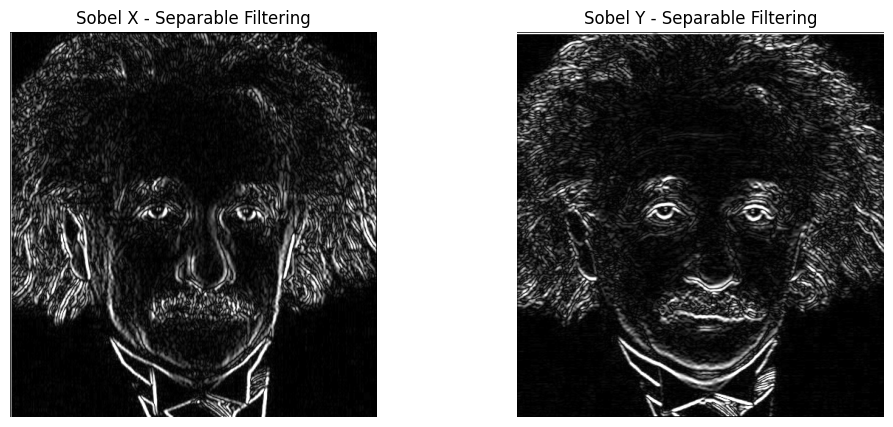

In [35]:
# Part (c) - Sobel filtering using separable filters

# ---------------------------------------
# Sobel X
# ---------------------------------------

# 3 x 1 filter
vertical_smoothing = np.array([
    [1],
    [2],
    [1]
], dtype=np.float32)

# 1 x 3 filter
horizontal_derivative = np.array([
    [1, 0, -1]
], dtype=np.float32)


# First filtering operation
temp_x = cv2.filter2D(
    gray,
    cv2.CV_32F,
    vertical_smoothing
)

# Second filtering operation
gx_separable = cv2.filter2D(
    temp_x,
    cv2.CV_32F,
    horizontal_derivative
)


# ---------------------------------------
# Sobel Y
# ---------------------------------------

# 3 x 1 filter
vertical_derivative = np.array([
    [1],
    [0],
    [-1]
], dtype=np.float32)

# 1 x 3 filter
horizontal_smoothing = np.array([
    [1, 2, 1]
], dtype=np.float32)


# First filtering operation
temp_y = cv2.filter2D(
    gray,
    cv2.CV_32F,
    horizontal_smoothing
)

# Second filtering operation
gy_separable = cv2.filter2D(
    temp_y,
    cv2.CV_32F,
    vertical_derivative
)


# Convert results for display
gx_sep_display = cv2.convertScaleAbs(gx_separable)
gy_sep_display = cv2.convertScaleAbs(gy_separable)


# Display results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gx_sep_display, cmap="gray")
plt.title("Sobel X - Separable Filtering")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gy_sep_display, cmap="gray")
plt.title("Sobel Y - Separable Filtering")
plt.axis("off")

plt.show()

**Question 09**

a)

In [63]:
img = cv2.imread("flower.png")
h, w, _ = img.shape
#initialoze mask and background/foreground models
mask = np.zeros((h, w), np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

rect = (int(w * 0.1), int(h * 0.15), int(w * 0.8), int(h * 0.65))

cv2.grabCut(img, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

binary_mask = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0).astype('uint8')

foreground = cv2.bitwise_and(img, img, mask=binary_mask)
background = cv2.bitwise_and(img, img, mask=1 - binary_mask)


cv2.imwrite('final_mask.png', binary_mask * 255)
cv2.imwrite('foreground.png', foreground)
cv2.imwrite('background.png', background)

True

b)

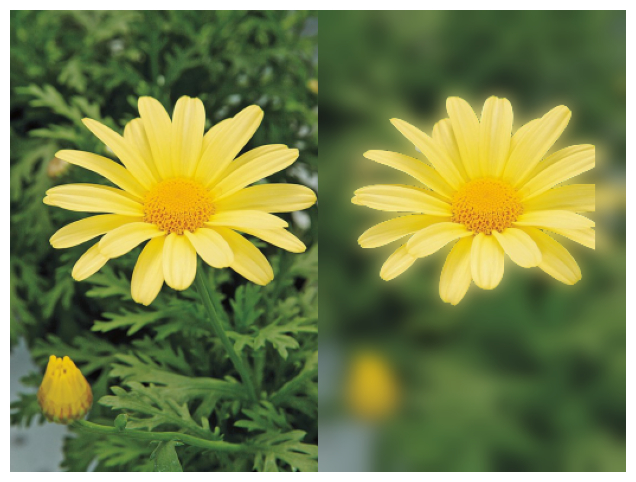

In [66]:
comparison_rgb = cv2.cvtColor(comparison, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(comparison_rgb)
plt.axis('off')
plt.show()